<a href="https://colab.research.google.com/github/alefo2003/alejofoglietta/blob/main/Entrega_Final_NLP_DL_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega Final — Data Science III
## NLP y Deep Learning sobre un dataset de tweets

**Dataset:** Twitter Dataset (Kaggle) — 10.000 tweets con columnas `Tweet_ID`, `Username`, `Text`, `Retweets`, `Likes`, `Timestamp`.

Este notebook cubre las tres partes de la Entrega Final:
1. Preprocesamiento de NLP (mínimo: 2 tareas — aquí se hacen 4).
2. Red neuronal simple (Deep Learning, mínimo).
3. Profundización: comparación de arquitecturas más profundas (Entrega Final).

**Cómo correr este notebook en Google Colab:**
1. Subí el archivo `twitter_dataset.csv` a la sesión de Colab (ícono de carpeta a la izquierda → *Upload*), o montá tu Google Drive.
2. Ajustá la variable `DATASET_PATH` en la celda siguiente con el nombre/ruta de tu archivo.
3. Ejecutá las celdas en orden (`Runtime` → `Run all`).

*Nota: se usa `scikit-learn` para todo (preprocesamiento y red neuronal) en lugar de `nltk`/`TensorFlow`/`PyTorch`, ya que no requiere descargar recursos externos y es igualmente válido para el objetivo del trabajo. Si tu entorno tiene internet (como Colab), podés reemplazarlo por `nltk` o `Keras` si tu docente lo pide específicamente — la lógica del código es la misma.*

In [1]:
# Si estás en Colab y no tenés estas librerías, descomentá la siguiente línea:
# !pip install scikit-learn pandas numpy matplotlib -q

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATASET_PATH = "twitter_dataset.csv"  # <-- ajustar según donde subiste el archivo

df = pd.read_csv(DATASET_PATH)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 10000 filas, 6 columnas


,Tweet_ID,Username,Text,Retweets,Likes,Timestamp
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21


## Parte 1 — Preprocesamiento de NLP

Se aplican cuatro tareas sobre la columna `Text`:
1. Limpieza de texto (minúsculas, remoción de URLs/menciones/puntuación).
2. Tokenización.
3. Eliminación de stopwords.
4. Vectorización (TF-IDF).

In [2]:
def limpiar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\.\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#", "", texto)
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["texto_limpio"] = df["Text"].apply(limpiar_texto)
df["tokens"] = df["texto_limpio"].apply(str.split)

STOPWORDS = set(ENGLISH_STOP_WORDS)
df["tokens_sin_stopwords"] = df["tokens"].apply(
    lambda toks: [t for t in toks if t not in STOPWORDS and len(t) > 1]
)
df["texto_final"] = df["tokens_sin_stopwords"].apply(lambda toks: " ".join(toks))
df["cant_tokens"] = df["tokens"].apply(len)
df["cant_tokens_sin_stopwords"] = df["tokens_sin_stopwords"].apply(len)

print("--- Ejemplo (primer tweet) ---")
print("Original:      ", df["Text"].iloc[0].replace("\n", " "))
print("Limpio:        ", df["texto_limpio"].iloc[0])
print("Tokens:        ", df["tokens"].iloc[0])
print("Sin stopwords: ", df["tokens_sin_stopwords"].iloc[0])

--- Ejemplo (primer tweet) ---
Original:       Party least receive say or single. Prevent prevent husband affect. May himself cup style evening protect. Effect another themselves stage perform. Possible try tax share style television with. Successful much sell development economy effect.
Limpio:         party least receive say or single prevent prevent husband affect may himself cup style evening protect effect another themselves stage perform possible try tax share style television with successful much sell development economy effect
Tokens:         ['party', 'least', 'receive', 'say', 'or', 'single', 'prevent', 'prevent', 'husband', 'affect', 'may', 'himself', 'cup', 'style', 'evening', 'protect', 'effect', 'another', 'themselves', 'stage', 'perform', 'possible', 'try', 'tax', 'share', 'style', 'television', 'with', 'successful', 'much', 'sell', 'development', 'economy', 'effect']
Sin stopwords:  ['party', 'receive', 'say', 'single', 'prevent', 'prevent', 'husband', 'affect', 'cup', 

In [3]:
vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(df["texto_final"])

print(f"Matriz TF-IDF: {tfidf_matrix.shape[0]} tweets x {tfidf_matrix.shape[1]} términos")
print("Ejemplo de términos aprendidos:", list(vectorizer.get_feature_names_out()[:15]))

Matriz TF-IDF: 10000 tweets x 500 términos
Ejemplo de términos aprendidos: ['ability', 'able', 'accept', 'account', 'act', 'action', 'activity', 'actually', 'add', 'address', 'admit', 'adult', 'affect', 'age', 'agency']


## Parte 2 — Red Neuronal Simple (Deep Learning)

**Problema:** regresión — predecir `Likes` a partir de `Retweets`, `cant_tokens` y `cant_tokens_sin_stopwords`.

**Arquitectura:** 1 capa oculta, 8 neuronas, activación ReLU.

In [4]:
FEATURES = ["Retweets", "cant_tokens", "cant_tokens_sin_stopwords"]
TARGET = "Likes"

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

modelo_simple = MLPRegressor(
    hidden_layer_sizes=(8,), activation="relu", solver="adam",
    max_iter=1000, random_state=42,
)
modelo_simple.fit(X_train_scaled, y_train)

y_pred = modelo_simple.predict(X_test_scaled)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2:  {r2_score(y_test, y_pred):.4f}")

MSE: 850.32
MAE: 25.32
R2:  -0.0013


Un R² cercano a 0 indica que el modelo no encuentra relación real entre las variables. Esto es esperado: en este dataset, `Likes` y `Retweets` fueron generados de forma aleatoria e independiente, sin relación real con el texto ni entre sí. Este punto se retoma en la Parte 3.

## Parte 3 — Profundización: comparación de arquitecturas (Entrega Final)

Se comparan tres arquitecturas, todas entrenadas con el mismo número de iteraciones (500, sin early stopping) para una comparación justa:

- **A. Simple:** (8,) — 1 capa oculta
- **B. Profunda:** (16, 8) — 2 capas ocultas
- **C. Profunda:** (32, 16, 8) — 3 capas ocultas

In [5]:
arquitecturas = {
    "A. Simple (8,)": (8,),
    "B. Profunda (16,8)": (16, 8),
    "C. Profunda (32,16,8)": (32, 16, 8),
}

resultados = {}
curvas_perdida = {}

for nombre, capas in arquitecturas.items():
    modelo = MLPRegressor(
        hidden_layer_sizes=capas, activation="relu", solver="adam",
        max_iter=500, n_iter_no_change=500, random_state=42,
    )
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados[nombre] = {"MSE": mse, "MAE": mae, "R2": r2}
    curvas_perdida[nombre] = modelo.loss_curve_
    print(f"{nombre:25s} | MSE: {mse:7.2f} | MAE: {mae:6.2f} | R2: {r2:8.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


A. Simple (8,)            | MSE:  850.16 | MAE:  25.32 | R2:  -0.0011


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


B. Profunda (16,8)        | MSE:  849.60 | MAE:  25.32 | R2:  -0.0004
C. Profunda (32,16,8)     | MSE:  849.04 | MAE:  25.32 | R2:   0.0002


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


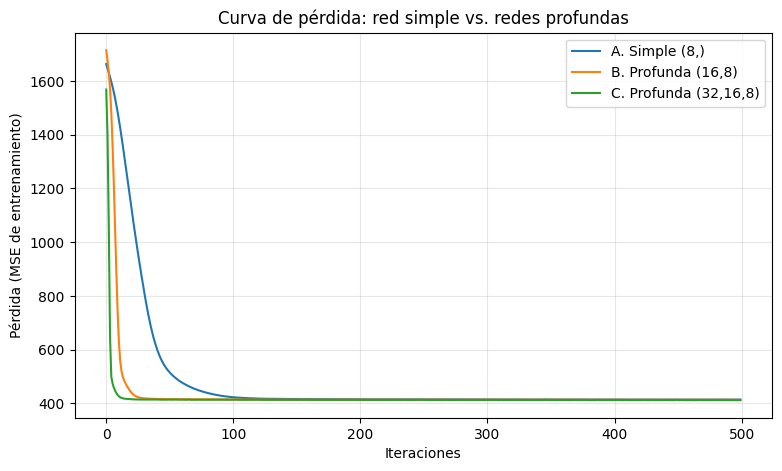

In [6]:
plt.figure(figsize=(9, 5))
for nombre, curva in curvas_perdida.items():
    plt.plot(curva, label=nombre)
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida (MSE de entrenamiento)")
plt.title("Curva de pérdida: red simple vs. redes profundas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusión

Las tres arquitecturas convergen prácticamente al mismo error (MSE ~849–850, MAE ~25.3), sin mejoras significativas al agregar capas y neuronas.

Esto **no es una falla del modelo ni del entrenamiento**, sino evidencia de que la limitación está en los datos y no en la arquitectura: como `Likes` y `Retweets` se generaron sin relación real entre sí ni con el contenido textual, ninguna red —por más profunda que sea— puede aprender un patrón que no existe.

Este hallazgo es metodológicamente válido para la Entrega Final: demuestra la capacidad de diagnosticar cuándo un bajo desempeño se origina en la naturaleza de los datos y no en la complejidad del modelo, evitando sobre-ingeniería de una red cuando el dataset no lo justifica.